* Week 5 Demo

Slight variations of week 4 demo - see more detail there.

Mostly we discussed subtleties of the code in class

In [48]:
import torch
import torch.nn.functional as F
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset  # Data stuff!

from sklearn.datasets import make_classification
import matplotlib.pyplot as plt
%matplotlib inline

# Just changes how numbers display
torch.set_printoptions(sci_mode=False, precision=2)

# Build some synthetic data
X, y = make_classification(n_samples=200, n_features=2, n_informative=2, n_redundant=0, n_repeated=0, n_clusters_per_class=1, random_state=5)

X_val, y_val = torch.tensor(X[100:], dtype=torch.float32), torch.tensor(y[100:], dtype=torch.long)
X_train, y_train = torch.tensor(X[:100], dtype=torch.float32), torch.tensor(y[:100], dtype=torch.long)

train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=10, shuffle=True)  
val_loader = DataLoader(TensorDataset(X_val, y_val), batch_size=50, shuffle=True)  

def show_decision_boundary(model, npoints=200):
    # Plot the nonlinear classifier boundary!
    plt.scatter(X[y==0,0], X[y==0,1], label='y=0')
    plt.scatter(X[y==1,0], X[y==1,1], label='y=1')
    plt.legend()

    x_min, x_max = -4, 4
    y_min, y_max = -4, 4
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, npoints), np.linspace(y_min, y_max, npoints))

    # Use the model to predict the class for each point on the grid
    with torch.no_grad():
        grid = torch.from_numpy(np.c_[xx.ravel(), yy.ravel()]).float()
        logits = model(grid)
        probabilities = torch.softmax(logits, dim=1)[:,0].numpy()

    # Reshape the probabilities back into the grid shape
    probs = probabilities.reshape(xx.shape)

    # Plot the contour plot of the decision boundary
    plt.contourf(xx, yy, probs, levels=[0, 0.5, 1], alpha=0.5, cmap='RdBu')
    plt.colorbar(label='Probability')
    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    plt.title('Decision Boundary of the MLP')
    plt.show()

In [49]:
class MyMLP(nn.Module):
    def __init__(self, n_hidden=5):
        super(MyMLP, self).__init__()
        self.fc1 = nn.Linear(2, n_hidden) 
        self.fc2 = nn.Linear(n_hidden, n_hidden)       
        self.fc3 = nn.Linear(n_hidden, 2)
        
    def forward(self, x):
        h1 = F.relu(self.fc1(x)) 
        h2 = F.relu(self.fc2(h1))
        logits = self.fc3(h2)
        return logits

In [55]:
class MyMLP(nn.Module):
    def __init__(self, n_hidden=5):
        super(MyMLP, self).__init__()
        self.fc1 = nn.Linear(2, n_hidden)
        self.drop1 = nn.Dropout(0.5)
        self.fc2 = nn.Linear(n_hidden, n_hidden) 
        self.drop2 = nn.Dropout(0.5)
        self.fc3 = nn.Linear(n_hidden, 2)
        
    def forward(self, x):
        h1 = F.relu(self.fc1(x))
        h1 = self.drop1(h1)
        h2 = F.relu(self.fc2(h1))
        h2 = self.drop1(h1)  # Bug! drop1 instead of drop2.. but doesn't matter in this case
        logits = self.fc3(h2)
        return logits

In [53]:
# Training loop
model = MyMLP(n_hidden=10)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.01, weight_decay=0.)

n_epochs = 300
for i in range(n_epochs):
    model.zero_grad()  # reset gradients
    for x_batch, y_batch in train_loader:

        logits = model(x_batch)
        loss = criterion(logits, y_batch)  # forward
        loss.backward()  # backward
    optimizer.step()  # gradient descent step
        
    # Validation loop, every k epochs
    model.eval()  # !!!
    val_loss = 0.
    with torch.no_grad(): 
        for x_batch, y_batch in val_loader:
            logits = model(x_batch)
            loss = criterion(logits, y_batch)
            val_loss += loss.item() / len(val_loader)
    print(f'Val Loss: {val_loss:.3f}')
    model.train()  # !!! 

Val Loss: 0.689
Val Loss: 0.670
Val Loss: 0.641
Val Loss: 0.620
Val Loss: 0.601
Val Loss: 0.590
Val Loss: 0.578
Val Loss: 0.569
Val Loss: 0.555
Val Loss: 0.544
Val Loss: 0.536
Val Loss: 0.526
Val Loss: 0.521
Val Loss: 0.511
Val Loss: 0.498
Val Loss: 0.492
Val Loss: 0.482
Val Loss: 0.474
Val Loss: 0.466
Val Loss: 0.455
Val Loss: 0.448
Val Loss: 0.439
Val Loss: 0.431
Val Loss: 0.425
Val Loss: 0.420
Val Loss: 0.415
Val Loss: 0.410
Val Loss: 0.401
Val Loss: 0.394
Val Loss: 0.387
Val Loss: 0.382
Val Loss: 0.377
Val Loss: 0.369
Val Loss: 0.362
Val Loss: 0.356
Val Loss: 0.350
Val Loss: 0.346
Val Loss: 0.340
Val Loss: 0.336
Val Loss: 0.330
Val Loss: 0.324
Val Loss: 0.321
Val Loss: 0.314
Val Loss: 0.310
Val Loss: 0.305
Val Loss: 0.301
Val Loss: 0.298
Val Loss: 0.296
Val Loss: 0.293
Val Loss: 0.289
Val Loss: 0.286
Val Loss: 0.282
Val Loss: 0.279
Val Loss: 0.276
Val Loss: 0.273
Val Loss: 0.269
Val Loss: 0.265
Val Loss: 0.263
Val Loss: 0.261
Val Loss: 0.257
Val Loss: 0.255
Val Loss: 0.252
Val Loss

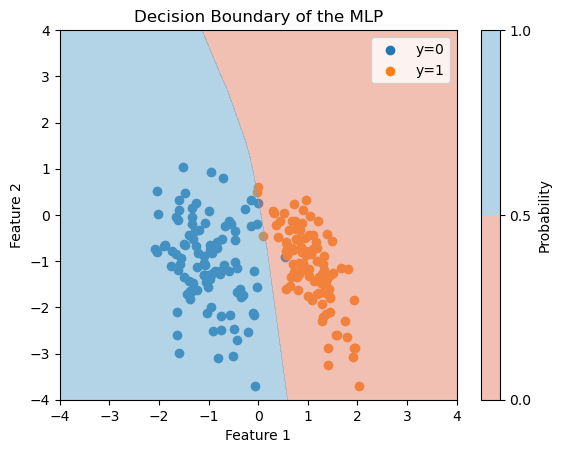

In [54]:
model.eval()  # What happens if we forget to turn off dropout!!
# model.train()
show_decision_boundary(model, npoints=400)